# RAMP sufficiency load profiles — Ixiamas and Santos_Mercado

Plots of the RAMP total-sufficiency output (full-year file only, no seasonal split).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

communities = ["Ixiamas", "Santos_Mercado"]
city = "Santos_Mercado"  # used by the single-community plots

all_data = {}
for comm in communities:
    folder = f"data ramp/{comm}/"
    year = pd.read_csv(folder + "load_curve_energy_service_full_year_Norte_Amazonia.csv", sep=",")

    year["total_load"] = year.drop(columns=["time"]).sum(axis=1)
    # time is in minutes; loads in W -> kW
    year["day"] = year["time"] / 1440
    year["total_load_k"] = year["total_load"] / 1000

    all_data[comm] = {"year": year}

In [2]:
def format_yearly_xaxis(ax):
    month_days = [0, 31, 62, 90, 121, 151, 182, 213, 244, 274, 305, 335]
    month_labels = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    ax.set_xticks(month_days)
    ax.set_xticklabels(month_labels, fontsize=12)
    ax.set_xlim(0, 365)
    ax.set_xlabel("Month", fontsize=14)
    ax.tick_params(axis='y', labelsize=12)

    seasons = [
        ("Summer", 0, 90, 'red'),
        ("Fall", 90, 182, 'orange'),
        ("Winter", 182, 274, 'blue'),
        ("Spring", 274, 365, 'green')
    ]
    for name, start, end, color in seasons:
        ax.axvspan(start, end, color=color, alpha=0.08)
        ax.text((start + end) / 2, 0.98, name, transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=11, color=color, weight='bold', alpha=0.6)

## First week of the year

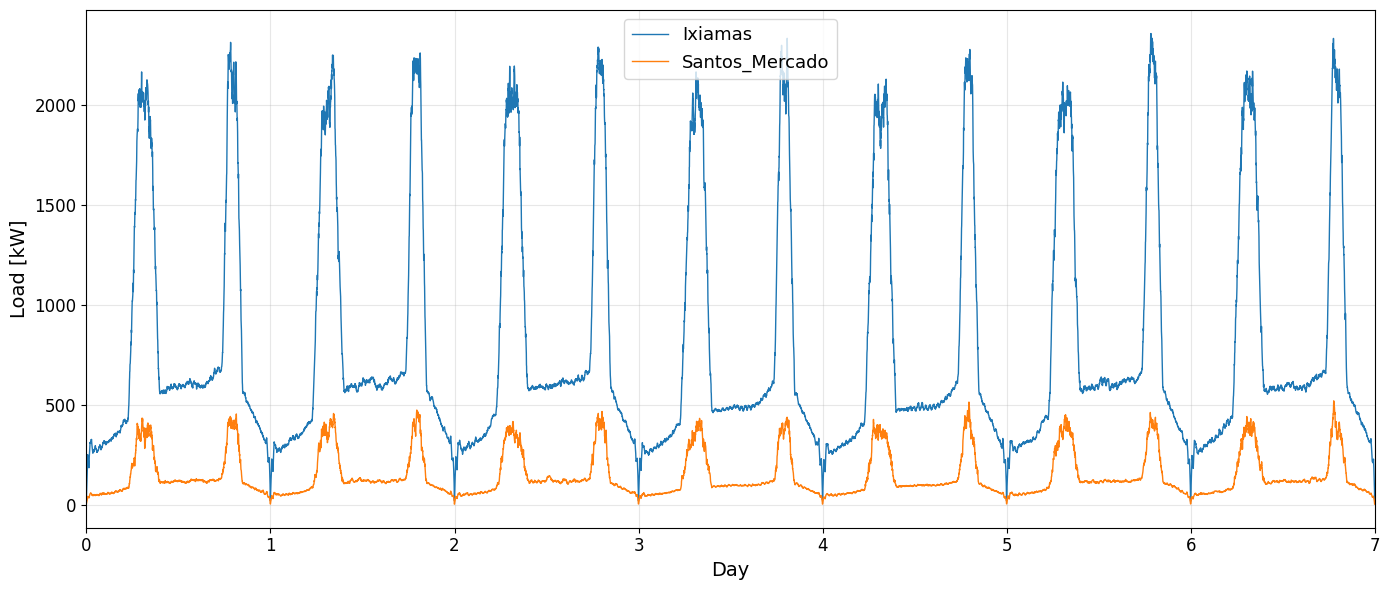

In [3]:
n_days = 7
n_points = n_days * 1440

plt.figure(figsize=(14,6))

for comm in communities:
    df_year = all_data[comm]["year"]
    plt.plot(df_year["day"][:n_points], df_year["total_load_k"][:n_points], label=f"{comm}", linewidth=1.0)

plt.xlabel("Day", fontsize=14)
plt.ylabel("Load [kW]", fontsize=14)
plt.xlim(0, n_days)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.legend(frameon=True, fontsize=13)
plt.tight_layout()
plt.show()

## Daily mean load over the year

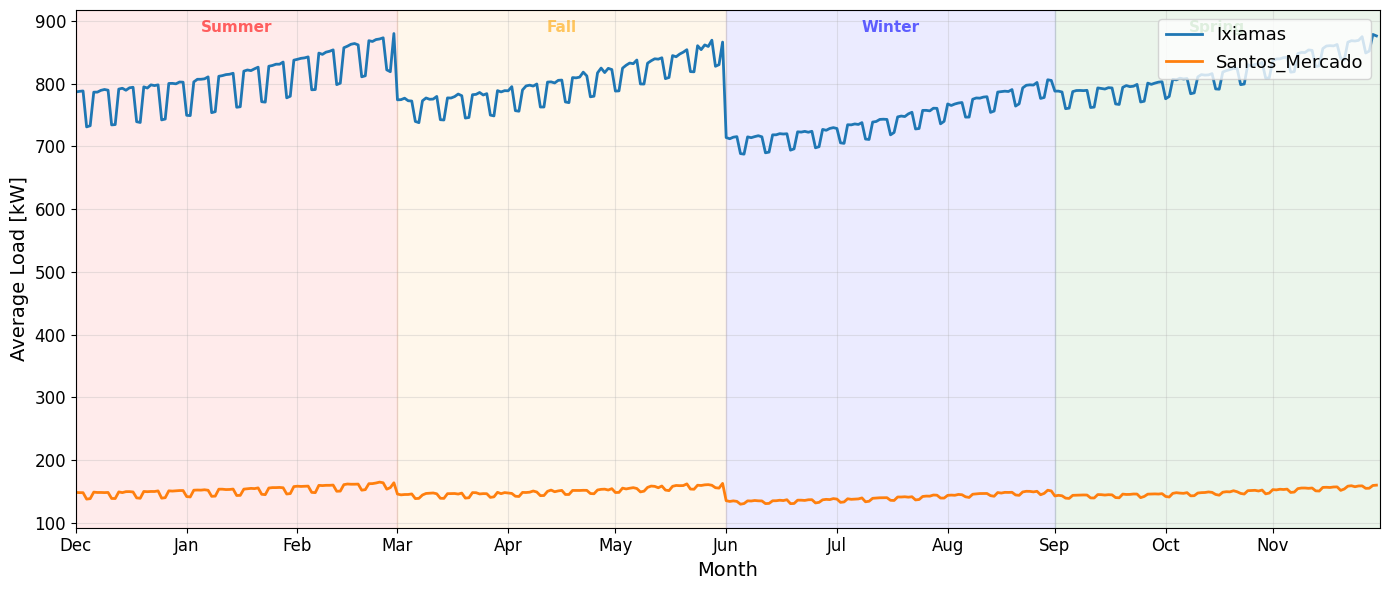

In [4]:
fig, ax = plt.subplots(figsize=(14,6))

for comm in communities:
    df_year = all_data[comm]["year"].copy()
    df_year["day_index"] = df_year["time"] // 1440
    daily_mean = df_year.groupby("day_index")["total_load_k"].mean()

    ax.plot(daily_mean.index, daily_mean.values, linewidth=2, label=f"{comm}")

ax.set_ylabel("Average Load [kW]", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True, fontsize=13, loc="upper right")

format_yearly_xaxis(ax)

plt.tight_layout()
plt.show()

## Load duration curve

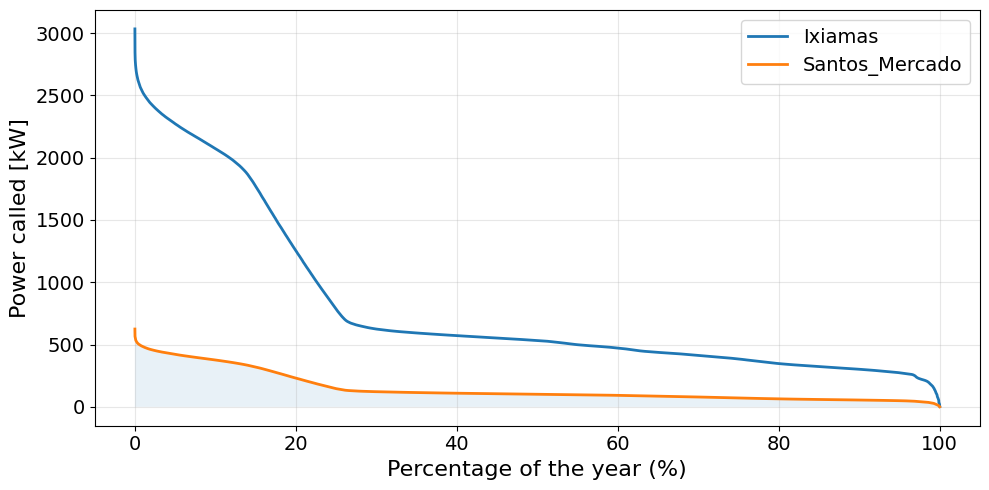

In [5]:
plt.figure(figsize=(10,5))

for comm in communities:
    sorted_load = all_data[comm]["year"]["total_load_k"].sort_values(ascending=False).values
    pourcentage_temps = (pd.Series(range(len(sorted_load))) / len(sorted_load)) * 100
    plt.plot(pourcentage_temps, sorted_load, label=comm, linewidth=2)

plt.xlabel("Percentage of the year (%)", fontsize=16)
plt.ylabel("Power called [kW]", fontsize=16)
plt.grid(True, alpha=0.3)
plt.fill_between(pourcentage_temps, 0, sorted_load, alpha=0.1)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## 24-hour composition, Santos_Mercado (five largest uses, day 1)

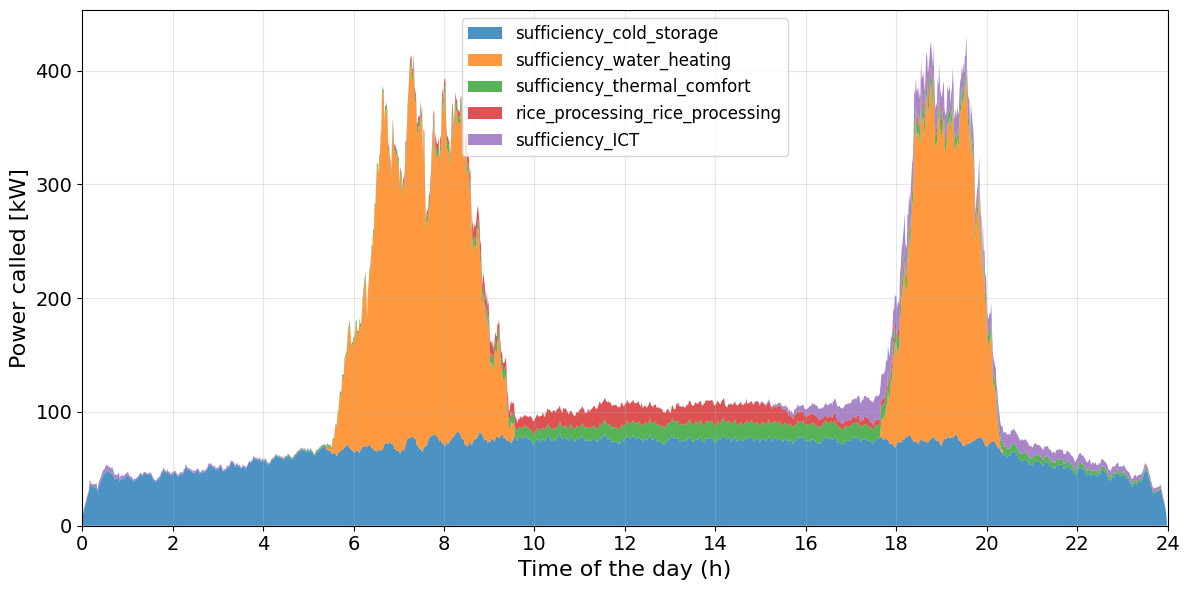

In [6]:
heures = pd.Series(range(1440)) / 60

df_day1 = all_data[city]["year"].iloc[:1440].copy()
colonnes_to_ignore = ["time", "day", "total_load", "total_load_k"]
df_usages = df_day1.drop(columns=colonnes_to_ignore)
top_5_usages = df_usages.sum().nlargest(5).index

donnees_empilees = [df_usages[usage]/1000 for usage in top_5_usages]

plt.figure(figsize=(12,6))
plt.stackplot(heures, donnees_empilees, labels=top_5_usages, alpha=0.8)

plt.xlabel("Time of the day (h)", fontsize=16)
plt.ylabel("Power called [kW]", fontsize=16)
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.tick_params(labelsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Space cooling per household over the year

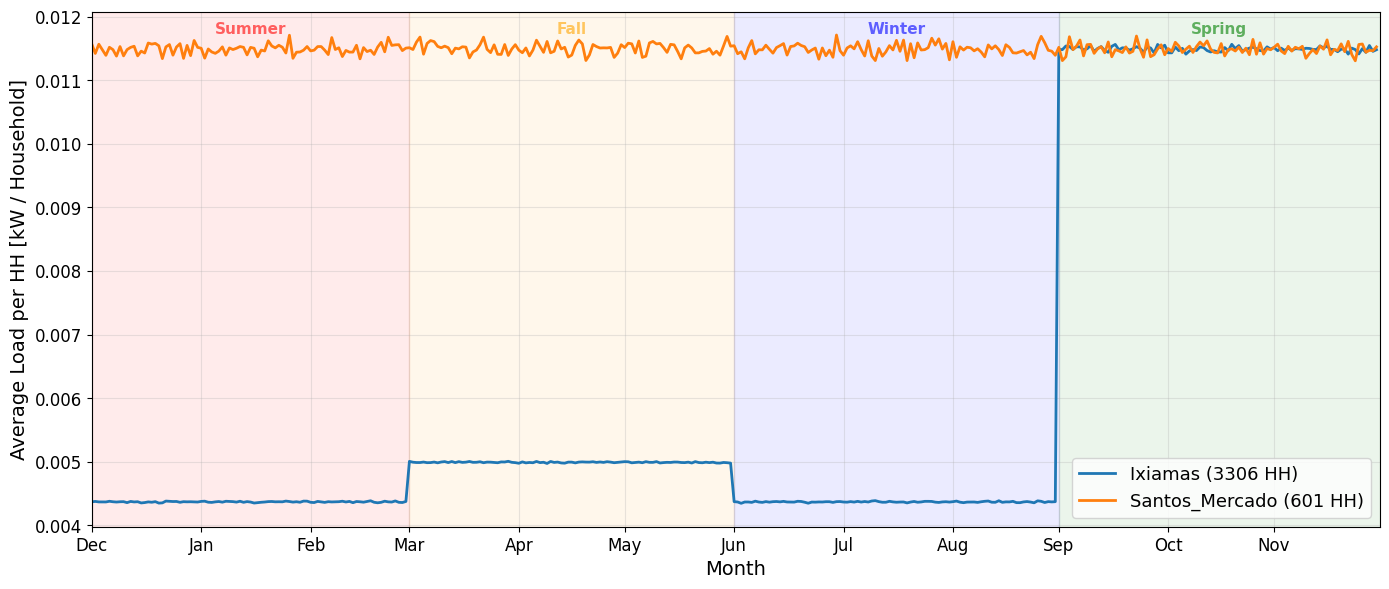

In [7]:
df_counts = pd.read_csv("../../exctraction of data/output/municipalities_counts_total.csv", sep=",")
hh_counts = dict(zip(df_counts["municipality"], df_counts["total_hh"]))

fig, ax = plt.subplots(figsize=(14,6))

for comm in communities:
    df_year = all_data[comm]["year"].copy()

    if "sufficiency_thermal_comfort" in df_year.columns:
        hh_number = hh_counts.get(comm, 1)
        df_year["thermal_k_per_hh"] = (df_year["sufficiency_thermal_comfort"] / 1000) / hh_number
        df_year["day_index"] = df_year["time"] // 1440
        daily_thermal = df_year.groupby("day_index")["thermal_k_per_hh"].mean()
        ax.plot(daily_thermal.index, daily_thermal.values, linewidth=2, label=f"{comm} ({int(hh_number)} HH)")
    else:
        print(f"No thermal comfort data for {comm}")

ax.set_ylabel("Average Load per HH [kW / Household]", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True, fontsize=13, loc="best")

format_yearly_xaxis(ax)

plt.tight_layout()
plt.show()

## Santos_Mercado: rice processing and load by sector


=== Santos_Mercado Metrics ===
New Peak Demand: 624.31 kW
Annual Rice Processing Energy: 11,126 kWh


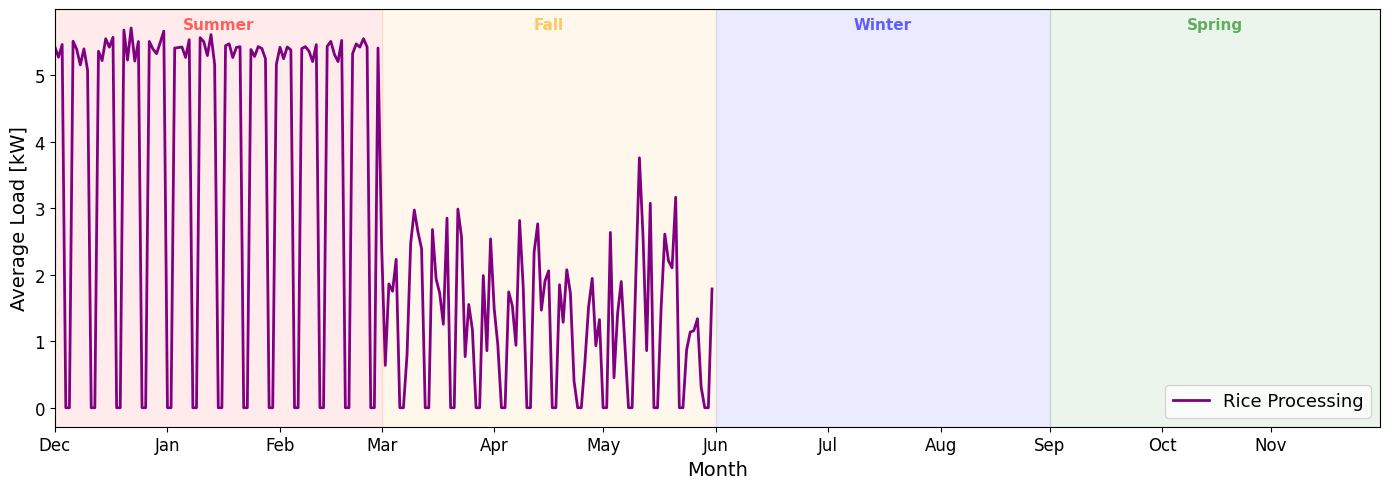

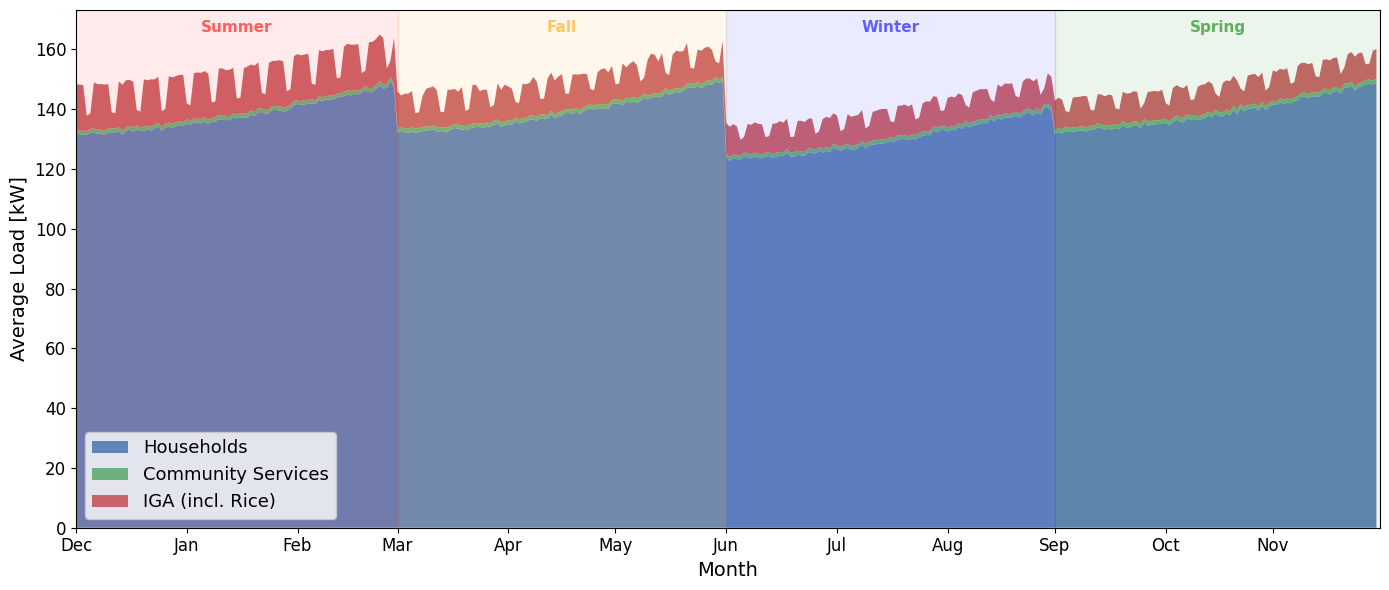

In [8]:
if city in all_data:
    df_year = all_data[city]["year"].copy()

    hh_cols  = [c for c in df_year.columns if c.startswith("sufficiency_")]
    cs_cols  = [c for c in df_year.columns if "school" in c or "health_center" in c or "public_lighting" in c]
    iga_cols = [c for c in df_year.columns if "store" in c or "restaurant" in c or "workshop" in c
                or "business" in c or "rice_processing" in c or "flour_processing" in c]

    df_year["total_hh_kW"]        = df_year[hh_cols].sum(axis=1) / 1000
    df_year["total_cs_kW"]        = df_year[cs_cols].sum(axis=1) / 1000
    df_year["total_iga_kW"]       = df_year[iga_cols].sum(axis=1) / 1000
    df_year["total_community_kW"] = df_year["total_hh_kW"] + df_year["total_cs_kW"] + df_year["total_iga_kW"]

    rice_col = [c for c in df_year.columns if "rice_processing" in c]
    df_year["rice_kW"] = df_year[rice_col[0]] / 1000 if rice_col else 0

    print(f"\n=== {city} Metrics ===")
    print(f"New Peak Demand: {df_year['total_community_kW'].max():.2f} kW")
    print(f"Annual Rice Processing Energy: {df_year['rice_kW'].sum() / 60:,.0f} kWh")

    df_year["day_index"] = df_year["time"] // 1440

    fig, ax = plt.subplots(figsize=(14,5))
    daily_rice = df_year.groupby("day_index")["rice_kW"].mean()
    ax.plot(daily_rice.index, daily_rice.values, linewidth=2, color="purple", label="Rice Processing")

    ax.set_ylabel("Average Load [kW]", fontsize=14)
    ax.legend(frameon=True, loc="best", fontsize=13)
    format_yearly_xaxis(ax)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14,6))
    daily_hh  = df_year.groupby("day_index")["total_hh_kW"].mean()
    daily_cs  = df_year.groupby("day_index")["total_cs_kW"].mean()
    daily_iga = df_year.groupby("day_index")["total_iga_kW"].mean()

    ax.stackplot(daily_hh.index, daily_hh.values, daily_cs.values, daily_iga.values,
                 labels=["Households", "Community Services", "IGA (incl. Rice)"],
                 colors=["#4c72b0", "#55a868", "#c44e52"], alpha=0.85)

    ax.set_ylabel("Average Load [kW]", fontsize=14)
    ax.legend(loc="best", frameon=True, fontsize=13)
    format_yearly_xaxis(ax)
    plt.tight_layout()
    plt.show()

## Fan usage time per municipality and season

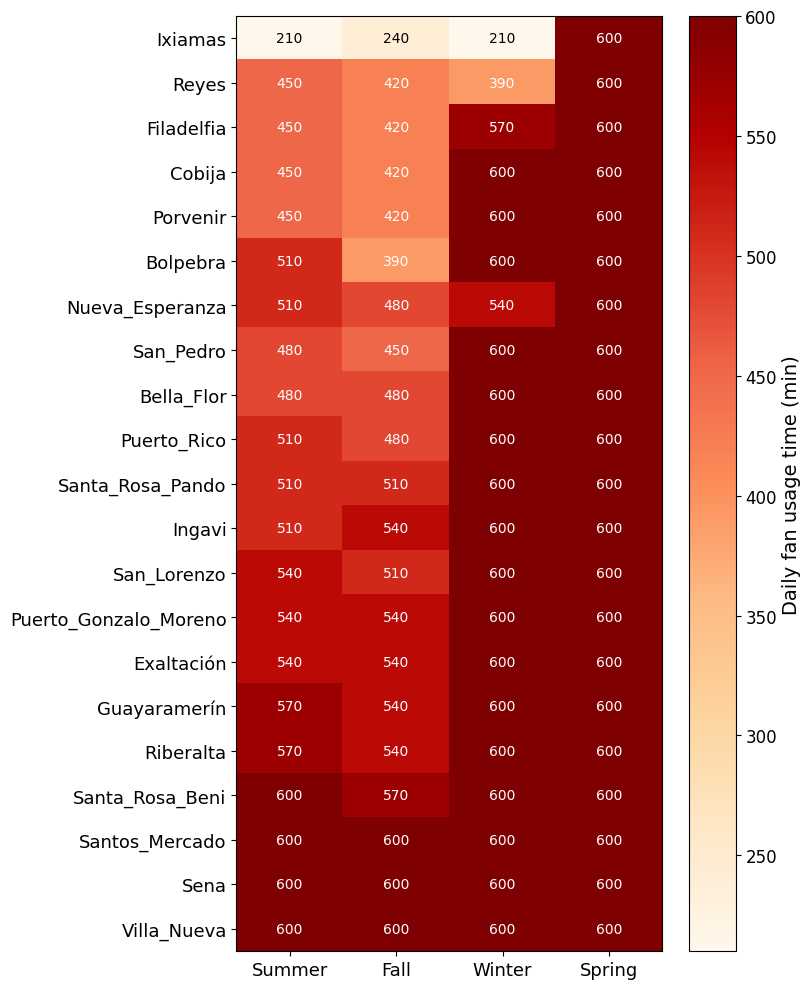

In [9]:
df_lookup = pd.read_csv("../../renewable ninja/temperature/output/thermal_comfort_lookup.csv")

heatmap_df = df_lookup.pivot(index="municipality", columns="season", values="func_time")

seasons_order = ['summer', 'fall', 'winter', 'spring']
heatmap_df = heatmap_df[seasons_order]

heatmap_df['annual_mean'] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values("annual_mean", ascending=True)
heatmap_df = heatmap_df.drop(columns=['annual_mean'])

fig, ax = plt.subplots(figsize=(8, 10))
cax = ax.imshow(heatmap_df.values, cmap="OrRd", aspect="auto")

ax.set_xticks(range(len(seasons_order)))
ax.set_xticklabels([s.capitalize() for s in seasons_order], fontsize=13)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=13)

cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Daily fan usage time (min)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

heatmap_array = heatmap_df.values
max_val = np.nanmax(heatmap_array)

for i in range(heatmap_array.shape[0]):
    for j in range(heatmap_array.shape[1]):
        val = heatmap_array[i, j]
        text_color = "white" if val > (max_val * 0.6) else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.show()